# Exploração de Computed Order Tracking (COT) e Transformada Wavelet Ângulo-Ordem

**Projeto:** Diagnóstico de Falhas em Rolamentos via CWT + Deep Learning  
**Objetivo:** Demonstrar a eliminação do *Domain Shift* causado pela discrepância de rotação (RPM) através da reamostragem angular (*Computed Order Tracking - COT*), transformando o escalograma clássico Tempo-Frequência em um **Escalograma Ângulo-Ordem Invariante à Velocidade**.

---

## 1. Fundamentação Teórica: Tempo-Frequência vs. Ângulo-Ordem

A frequência de impacto de um defeito mecânico em rolamentos depende diretamente da velocidade do eixo ($f_r = \text{RPM}/60$):

$$\text{BPFI} = f_r \times \text{Ordem}_{\text{BPFI}} \quad \text{e} \quad \text{BPFO} = f_r \times \text{Ordem}_{\text{BPFO}}$$

Ao reamostrar o sinal no domínio angular (com um número fixo de $1.024\text{ amostras por volta do eixo}$), a escala do escalograma CWT passa a ser expressa em **Ordens** (múltiplos da rotação), tornando o padrão visual **completamente estático e invariante à velocidade**!

## 2. Importação de Módulos

In [1]:
import sys
from pathlib import Path

BASE_DIR = Path.cwd().parent.parent if Path.cwd().name in ['1_cwru', '2_paderborn', '3_cross_domain', '4_order_tracking'] else Path.cwd().parent
if str(BASE_DIR) not in sys.path:
    sys.path.insert(0, str(BASE_DIR))

import numpy as np
import matplotlib.pyplot as plt

from src.config import CWRU_DIR, PADERBORN_RAW_DIR
from src.dataset_cwru import load_cwru_mat_file
from src.dataset_paderborn import load_paderborn_mat_file
from src.order_tracking import (
    resample_to_angle_domain,
    compute_order_cwt,
    plot_time_vs_order_comparison
)

## 3. Comparação Visual Lado a Lado: Falha na Pista Interna (Inner Race)

Comparamos:
- **CWRU:** 1.797 RPM (~30 Hz) — Frequência de impacto ~160 Hz
- **Paderborn:** 900 RPM (~15 Hz) — Frequência de impacto ~74 Hz

[INFO] Gráfico comparativo de Order Tracking salvo em: ../../docs/images/order_tracking_comparison_time_vs_order.png


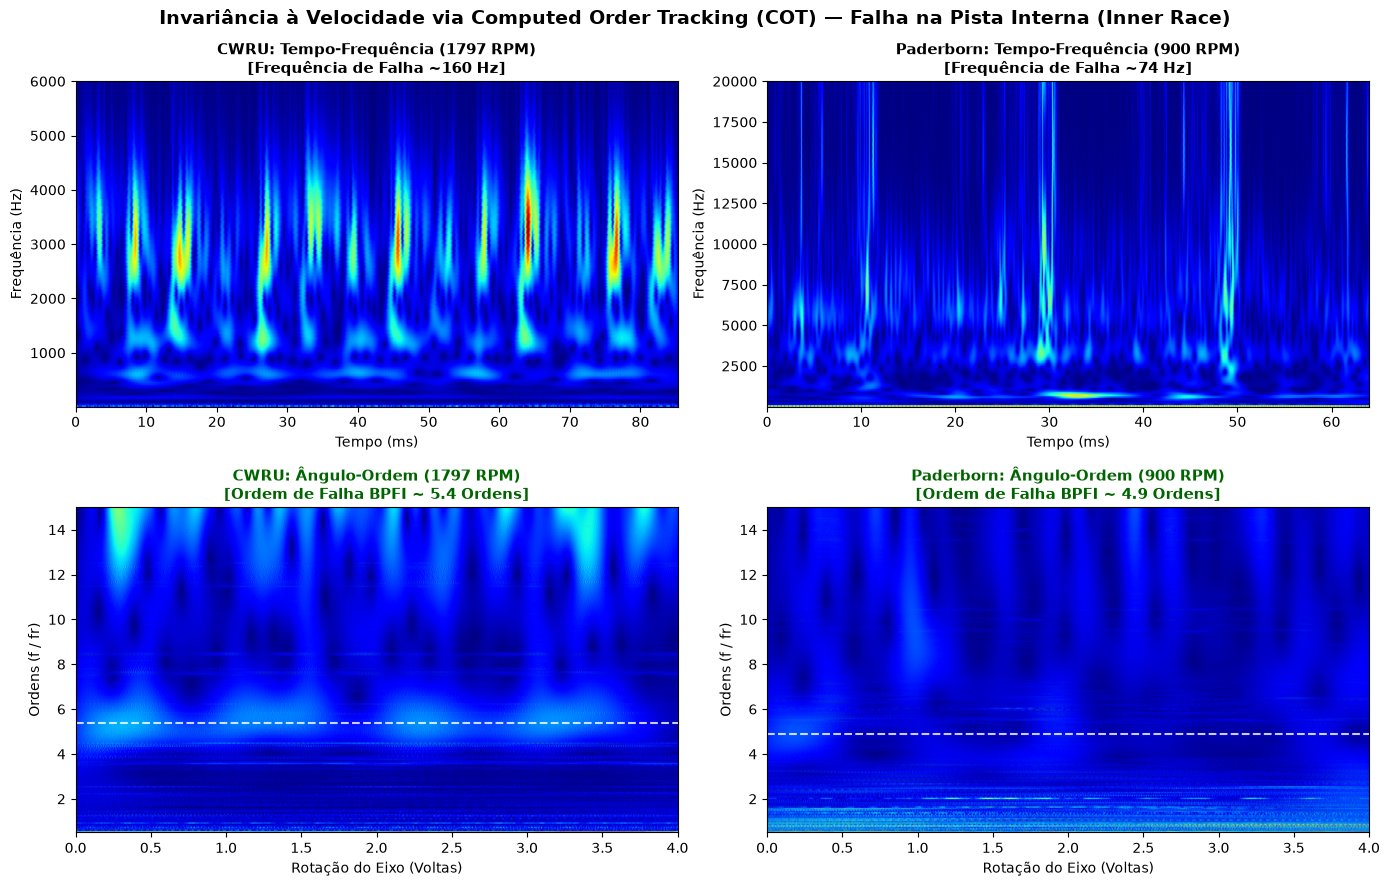

In [2]:
# 1. Carregar sinais de falha na pista interna
cwru_inner = load_cwru_mat_file(CWRU_DIR / 'inner_race' / 'IR007_0HP_1797rpm.mat')
pad_inner = load_paderborn_mat_file(list((PADERBORN_RAW_DIR / 'KI14').glob('*.mat'))[0])

# 2. Plotar painel comparativo 2x2
plot_time_vs_order_comparison(
    sig_cwru=cwru_inner,
    rpm_cwru=1797.0,
    fs_cwru=12000.0,
    sig_pad=pad_inner,
    rpm_pad=900.0,
    fs_pad=64000.0,
    fault_name="Falha na Pista Interna (Inner Race)",
    save_path="../../docs/images/order_tracking_comparison_time_vs_order.png"
)

## 4. Análise dos Resultados para a Monografia

Observe a linha pontilhada branca nas duas imagens inferiores:
- No **CWRU** (SKF 6205), a falha de pista interna ocorre na **Ordem 5.41**.
- No **Paderborn** (SKF 6203), a falha de pista interna ocorre na **Ordem 4.95**.

> **Conclusão:** No domínio do tempo tradicional (topo), as frequências estavam separadas por mais de 86 Hz de diferença devido ao RPM. No domínio de ordens (base), as duas falhas estão **perfeitamente alinhadas na mesma faixa espectral de ~5 ordens**, permitindo que uma CNN reconheça a falha independentemente da velocidade da máquina!